In [1]:
# ======================================
# model_training - Setup 
# ======================================

from pathlib import Path
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

# ---- Paths ----
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

PRICE_FILE = RAW_DIR / "prices.parquet"

# 🔥 CHANGE THIS LINE ONLY
FEATURE_FILE = PROCESSED_DIR / "features_v3.parquet"

# ---- Load data ----
prices = pd.read_parquet(PRICE_FILE)
features = pd.read_parquet(FEATURE_FILE)

# ---- Date handling ----
prices["date"] = pd.to_datetime(prices["date"])
features["date"] = pd.to_datetime(features["date"])

# ---- Sorting ----
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

# ---- Diagnostics ----
print("Prices shape:", prices.shape)
print("Features shape:", features.shape)

print("\nFeature columns:")
print(features.columns.tolist())

features.head()

Prices shape: (1903828, 8)
Features shape: (1903828, 17)

Feature columns:
['date', 'ticker', 'ret_6m', 'ret_12m', 'vol_12m', 'drawdown', 'pe_ratio', 'earnings_yield', 'ret_6m_rank', 'ret_12m_rank', 'vol_12m_rank', 'drawdown_rank', 'low_vol_rank', 'momentum_vol_adj', 'momentum_composite', 'quality_value_combo', 'sector']


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,vol_12m_rank,drawdown_rank,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,0.5,0.501182,0.5,0.0,NaN,NaN,Healthcare
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,0.5,0.193396,0.5,0.0,NaN,NaN,Healthcare
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,0.5,0.212264,0.5,0.0,NaN,NaN,Healthcare
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,0.5,0.252358,0.5,0.0,NaN,NaN,Healthcare
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,0.5,0.306604,0.5,0.0,NaN,NaN,Healthcare


In [2]:
# ======================================
# Download / Build Benchmark Series
# ======================================

import yfinance as yf

BENCHMARK_TICKER = "SPY"
START_DATE = prices["date"].min().strftime("%Y-%m-%d")
END_DATE = (prices["date"].max() + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

benchmark = yf.download(
    BENCHMARK_TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    threads=False
)

benchmark.columns = [col[0] if isinstance(col, tuple) else col for col in benchmark.columns]

benchmark = benchmark.reset_index().rename(columns={
    "Date": "date",
    "Adj Close": "benchmark_adj_close"
})

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark = benchmark[["date", "benchmark_adj_close"]].sort_values("date").reset_index(drop=True)

print("Benchmark shape:", benchmark.shape)
benchmark

Benchmark shape: (4024, 2)


,date,benchmark_adj_close
0,2010-01-04,84.796371
1,2010-01-05,85.020836
2,2010-01-06,85.080666
3,2010-01-07,85.439842
4,2010-01-08,85.724159
...,...,...
4019,2025-12-24,688.499695
4020,2025-12-26,688.429871
4021,2025-12-29,685.976562
4022,2025-12-30,685.138916


In [3]:
# ======================================
# Create Forward 3-Year Stock Returns
# ======================================

FORWARD_DAYS = 252 * 3  # ~3 trading years

prices["fwd_3y_stock_return"] = (
    prices.groupby("ticker")["adj_close"]
    .shift(-FORWARD_DAYS) / prices["adj_close"] - 1
)

stock_forward_returns = prices[["date", "ticker", "fwd_3y_stock_return"]].copy()

stock_forward_returns

,date,ticker,fwd_3y_stock_return
0,2010-01-04,A,0.383023
1,2010-01-05,A,0.388098
2,2010-01-06,A,0.381916
3,2010-01-07,A,0.421081
4,2010-01-08,A,0.432034
...,...,...,...
1903823,2025-12-24,ZTS,NaN
1903824,2025-12-26,ZTS,NaN
1903825,2025-12-29,ZTS,NaN
1903826,2025-12-30,ZTS,NaN


In [4]:
# ======================================
# Create Forward 3-Year Benchmark Returns
# ======================================

benchmark["fwd_3y_benchmark_return"] = (
    benchmark["benchmark_adj_close"].shift(-FORWARD_DAYS) / benchmark["benchmark_adj_close"] - 1
)

benchmark_forward_returns = benchmark[["date", "fwd_3y_benchmark_return"]].copy()

benchmark_forward_returns

,date,fwd_3y_benchmark_return
0,2010-01-04,0.374334
1,2010-01-05,0.366960
2,2010-01-06,0.362068
3,2010-01-07,0.359790
4,2010-01-08,0.366054
...,...,...
4019,2025-12-24,NaN
4020,2025-12-26,NaN
4021,2025-12-29,NaN
4022,2025-12-30,NaN


In [5]:
# ======================================
# Create Binary Outperformance Label
# ======================================

labels = stock_forward_returns.merge(
    benchmark_forward_returns,
    on="date",
    how="left"
)

labels["excess_fwd_3y_return"] = (
    labels["fwd_3y_stock_return"] - labels["fwd_3y_benchmark_return"]
)

labels["label"] = (labels["excess_fwd_3y_return"] > 0.25).astype(int)

print(labels[["fwd_3y_stock_return", "fwd_3y_benchmark_return", "excess_fwd_3y_return", "label"]].describe())

labels

       fwd_3y_stock_return  fwd_3y_benchmark_return  excess_fwd_3y_return  \
count         1.525710e+06             1.525711e+06          1.525710e+06   
mean          6.339164e-01             4.748809e-01          1.590358e-01   
std           1.030639e+00             1.548953e-01          1.015065e+00   
min          -9.622105e-01             1.119535e-02         -1.750726e+00   
25%           1.719980e-01             3.524695e-01         -2.828703e-01   
50%           4.839141e-01             4.479892e-01          1.817800e-02   
75%           8.635639e-01             5.787040e-01          3.798509e-01   
max           1.179765e+02             1.112218e+00          1.171696e+02   

              label  
count  1.903828e+06  
mean   2.595250e-01  
std    4.383741e-01  
min    0.000000e+00  
25%    0.000000e+00  
50%    0.000000e+00  
75%    1.000000e+00  
max    1.000000e+00  


,date,ticker,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,label
0,2010-01-04,A,0.383023,0.374334,0.008689,0
1,2010-01-05,A,0.388098,0.366960,0.021138,0
2,2010-01-06,A,0.381916,0.362068,0.019848,0
3,2010-01-07,A,0.421081,0.359790,0.061290,0
4,2010-01-08,A,0.432034,0.366054,0.065980,0
...,...,...,...,...,...,...
1903823,2025-12-24,ZTS,NaN,NaN,NaN,0
1903824,2025-12-26,ZTS,NaN,NaN,NaN,0
1903825,2025-12-29,ZTS,NaN,NaN,NaN,0
1903826,2025-12-30,ZTS,NaN,NaN,NaN,0


In [6]:
labels.label.value_counts()

label
0    1409737
1     494091
Name: count, dtype: int64

In [7]:
features.columns

Index(['date', 'ticker', 'ret_6m', 'ret_12m', 'vol_12m', 'drawdown',
       'pe_ratio', 'earnings_yield', 'ret_6m_rank', 'ret_12m_rank',
       'vol_12m_rank', 'drawdown_rank', 'low_vol_rank', 'momentum_vol_adj',
       'momentum_composite', 'quality_value_combo', 'sector'],
      dtype='object')

In [8]:
# ======================================
# Build Modeling Table
# ======================================

model_df = features.merge(
    labels[[
        "date",
        "ticker",
        "fwd_3y_stock_return",
        "fwd_3y_benchmark_return",
        "excess_fwd_3y_return",
    ]],
    on=["date", "ticker"],
    how="left"
)

print("Model DF shape:", model_df.shape)
model_df.head()

Model DF shape: (1903828, 20)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,vol_12m_rank,drawdown_rank,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return
0,2010-01-04,A,NaN,NaN,NaN,0.000000,26.902868,0.037171,0.5,0.5,0.5,0.501182,0.5,0.0,NaN,NaN,Healthcare,0.383023,0.374334,0.008689
1,2010-01-05,A,NaN,NaN,NaN,-0.010863,26.902868,0.037171,0.5,0.5,0.5,0.193396,0.5,0.0,NaN,NaN,Healthcare,0.388098,0.366960,0.021138
2,2010-01-06,A,NaN,NaN,NaN,-0.014377,26.902868,0.037171,0.5,0.5,0.5,0.212264,0.5,0.0,NaN,NaN,Healthcare,0.381916,0.362068,0.019848
3,2010-01-07,A,NaN,NaN,NaN,-0.015655,26.902868,0.037171,0.5,0.5,0.5,0.252358,0.5,0.0,NaN,NaN,Healthcare,0.421081,0.359790,0.061290
4,2010-01-08,A,NaN,NaN,NaN,-0.015974,26.902868,0.037171,0.5,0.5,0.5,0.306604,0.5,0.0,NaN,NaN,Healthcare,0.432034,0.366054,0.065980


In [9]:
# ======================================
# Clean Modeling Table + Transform Target 
# ======================================

feature_cols = [
    # V1
    "ret_6m",
    "ret_12m",
    "vol_12m",
    "drawdown",

    # V2
    "pe_ratio",
    "earnings_yield",

    # V3
    "ret_6m_rank",
    "ret_12m_rank",
    "vol_12m_rank",
    "drawdown_rank",
    "momentum_vol_adj",
    "quality_value_combo"
]

target_col = "target"

# --- Clean ---
model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(
    subset=feature_cols + ["excess_fwd_3y_return"]
).reset_index(drop=True)

# --- log transform ---
model_df["target"] = np.sign(model_df["excess_fwd_3y_return"]) * \
                     np.log1p(np.abs(model_df["excess_fwd_3y_return"]))

# --- Diagnostics ---
print(model_df[feature_cols + ["sector", "excess_fwd_3y_return", "target"]].head())
print(model_df.shape)

print("\nFeature nulls:")
print(model_df[feature_cols].isnull().sum())

     ret_6m   ret_12m   vol_12m  drawdown   pe_ratio  earnings_yield  \
0  0.509190  0.338019  0.019335 -0.000955  26.902868        0.037171   
1  0.452223  0.340116  0.019331 -0.010258  26.902868        0.037171   
2  0.437001  0.341977  0.019330 -0.012405  26.902868        0.037171   
3  0.447818  0.346316  0.019329 -0.010497  26.902868        0.037171   
4  0.475887  0.351298  0.019330 -0.007157  26.902868        0.037171   

   ret_6m_rank  ret_12m_rank  vol_12m_rank  drawdown_rank  momentum_vol_adj  \
0     0.862150      0.699764      0.638298       0.780600         17.481356   
1     0.871495      0.724057      0.636792       0.787529         17.593151   
2     0.866822      0.733491      0.636792       0.713626         17.690515   
3     0.885514      0.742925      0.641509       0.773672         17.915599   
4     0.894860      0.757075      0.641509       0.849885         18.173225   

   quality_value_combo      sector  excess_fwd_3y_return    target  
0             0.805120 

In [10]:
# ======================================
# Downsample to Monthly Observations
# ======================================

model_df["year_month"] = model_df["date"].dt.to_period("M")

model_df_monthly = (
    model_df.sort_values("date")
    .groupby(["ticker", "year_month"])
    .tail(1)
    .reset_index(drop=True)
)

print("Daily shape  :", model_df.shape)
print("Monthly shape:", model_df_monthly.shape)

model_df_monthly.head()

Daily shape  : (1326140, 22)
Monthly shape: (63348, 22)


,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,target,year_month
0,2011-01-31,KDP,-0.047424,0.306040,0.016876,-0.104198,17.339870,0.057671,0.046620,0.577830,...,0.530660,18.133767,0.312225,1.318189,Consumer Defensive,0.468167,0.441076,0.027090,0.026730,2011-01
1,2011-01-31,DRI,0.129701,0.280426,0.016387,-0.059313,21.187567,0.047197,0.414918,0.528302,...,0.566038,17.111186,0.471610,1.247331,Consumer Cyclical,0.127669,0.441076,-0.313407,-0.272625,2011-01
2,2011-01-31,HSY,0.017207,0.305204,0.012225,-0.089241,44.487300,0.022478,0.128205,0.575472,...,0.844340,24.964260,0.351838,0.985217,Consumer Defensive,1.246273,0.441076,0.805197,0.590670,2011-01
3,2011-01-31,FIX,0.092513,0.093038,0.023145,-0.108482,57.149240,0.017498,0.312354,0.219340,...,0.174528,4.019692,0.265847,0.264598,Industrials,0.358457,0.441076,-0.082619,-0.079383,2011-01
4,2011-01-31,A,0.451422,0.435976,0.019251,-0.056821,26.902868,0.037171,0.941725,0.745283,...,0.337264,22.646128,0.843504,0.780682,Healthcare,0.369731,0.441076,-0.071345,-0.068915,2011-01


In [11]:
# ======================================
# Clean Modeling Table + Transform Target 
# ======================================

feature_cols = [
    # V1
    "ret_6m",
    "ret_12m",
    "vol_12m",
    "drawdown",

    # V2
    "pe_ratio",
    "earnings_yield",

    # V3
    "ret_6m_rank",
    "ret_12m_rank",
    "vol_12m_rank",
    "drawdown_rank",
    "momentum_vol_adj",
    "quality_value_combo"
]

target_col = "target"

# --- Clean ---
model_df = model_df.replace([np.inf, -np.inf], np.nan)

model_df = model_df.dropna(
    subset=feature_cols + ["excess_fwd_3y_return"]
).reset_index(drop=True)

# --- Log Transform Target  ---
model_df["target"] = np.sign(model_df["excess_fwd_3y_return"]) * \
                     np.log1p(np.abs(model_df["excess_fwd_3y_return"]))

# --- Diagnostics ---
print(model_df[feature_cols + ["sector", "excess_fwd_3y_return", "target"]].head())
print(model_df.shape)

print("\nFeature nulls:")
print(model_df[feature_cols].isnull().sum())

     ret_6m   ret_12m   vol_12m  drawdown   pe_ratio  earnings_yield  \
0  0.509190  0.338019  0.019335 -0.000955  26.902868        0.037171   
1  0.452223  0.340116  0.019331 -0.010258  26.902868        0.037171   
2  0.437001  0.341977  0.019330 -0.012405  26.902868        0.037171   
3  0.447818  0.346316  0.019329 -0.010497  26.902868        0.037171   
4  0.475887  0.351298  0.019330 -0.007157  26.902868        0.037171   

   ret_6m_rank  ret_12m_rank  vol_12m_rank  drawdown_rank  momentum_vol_adj  \
0     0.862150      0.699764      0.638298       0.780600         17.481356   
1     0.871495      0.724057      0.636792       0.787529         17.593151   
2     0.866822      0.733491      0.636792       0.713626         17.690515   
3     0.885514      0.742925      0.641509       0.773672         17.915599   
4     0.894860      0.757075      0.641509       0.849885         18.173225   

   quality_value_combo      sector  excess_fwd_3y_return    target  
0             0.805120 

In [12]:
model_df

,date,ticker,ret_6m,ret_12m,vol_12m,drawdown,pe_ratio,earnings_yield,ret_6m_rank,ret_12m_rank,...,low_vol_rank,momentum_vol_adj,momentum_composite,quality_value_combo,sector,fwd_3y_stock_return,fwd_3y_benchmark_return,excess_fwd_3y_return,target,year_month
0,2011-01-03,A,0.509190,0.338019,0.019335,-0.000955,26.902868,0.037171,0.862150,0.699764,...,0.361702,17.481356,0.780957,0.805120,Healthcare,0.380035,0.528197,-0.148162,-0.138163,2011-01
1,2011-01-04,A,0.452223,0.340116,0.019331,-0.010258,26.902868,0.037171,0.871495,0.724057,...,0.363208,17.593151,0.797776,0.806626,Healthcare,0.412927,0.538431,-0.125504,-0.118231,2011-01
2,2011-01-05,A,0.437001,0.341977,0.019330,-0.012405,26.902868,0.037171,0.866822,0.733491,...,0.363208,17.690515,0.800156,0.806626,Healthcare,0.439168,0.530810,-0.091641,-0.087682,2011-01
3,2011-01-06,A,0.447818,0.346316,0.019329,-0.010497,26.902868,0.037171,0.885514,0.742925,...,0.358491,17.915599,0.814219,0.801909,Healthcare,0.436885,0.534817,-0.097933,-0.093429,2011-01
4,2011-01-07,A,0.475887,0.351298,0.019330,-0.007157,26.902868,0.037171,0.894860,0.757075,...,0.358491,18.173225,0.825968,0.801909,Healthcare,0.444799,0.542022,-0.097222,-0.092782,2011-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326135,2022-12-19,ZTS,-0.112662,-0.384403,0.020128,-0.416101,20.328903,0.049191,0.145161,0.111111,...,0.567677,-19.097020,0.128136,1.285987,Healthcare,-0.094990,0.889898,-0.984888,-0.685562,2022-12
1326136,2022-12-20,ZTS,-0.128953,-0.387368,0.020129,-0.419037,20.328903,0.049191,0.131048,0.103030,...,0.563636,-19.243500,0.117039,1.281946,Healthcare,-0.085052,0.887125,-0.972177,-0.679138,2022-12
1326137,2022-12-21,ZTS,-0.139951,-0.385696,0.020138,-0.409047,20.328903,0.049191,0.120968,0.107071,...,0.563636,-19.151311,0.114019,1.281946,Healthcare,-0.102302,0.852697,-0.954999,-0.670390,2022-12
1326138,2022-12-22,ZTS,-0.166114,-0.395231,0.020106,-0.408598,20.328903,0.049191,0.131048,0.125253,...,0.567677,-19.656497,0.128150,1.285987,Healthcare,-0.099921,0.877216,-0.977136,-0.681649,2022-12


In [13]:
# ======================================
# Time-Based Split for Regression (Monthly)
# ======================================

train_end = pd.Timestamp("2017-12-31")
valid_end = pd.Timestamp("2020-12-31")

df = model_df_monthly.copy()

train_df = df[df["date"] <= train_end].copy()
valid_df = df[(df["date"] > train_end) & (df["date"] <= valid_end)].copy()
test_df  = df[df["date"] > valid_end].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_valid = valid_df[feature_cols]
y_valid = valid_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train:", X_train.shape, y_train.shape)
print("Valid:", X_valid.shape, y_valid.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (35926, 12) (35926,)
Valid: (16309, 12) (16309,)
Test : (11113, 12) (11113,)


In [14]:
# ======================================
# Train LightGBM Regressor
# ======================================

model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=1.0,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="l2",   # or "rmse"
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000792 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3051
[LightGBM] [Info] Number of data points in the train set: 35926, number of used features: 12
[LightGBM] [Info] Start training from score 0.104792
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 0.191718
[100]	valid_0's l2: 0.192483
Early stopping, best iteration is:
[50]	valid_0's l2: 0.191718


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [15]:
# ======================================
# Score Model + Calibrate Predictions 
# ======================================
from sklearn.isotonic import IsotonicRegression

# --- STEP 1: Process Validation Data ---
valid_df = valid_df.copy()
valid_preds = model.predict(X_valid)

valid_df["predicted_excess_return"] = np.sign(valid_preds) * (
    np.expm1(np.abs(valid_preds))
)

# --- Fit calibrator on validation ---
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(
    valid_df["predicted_excess_return"],
    valid_df["excess_fwd_3y_return"]
)


# --- STEP 2: Process Test Data ---
test_df = test_df.copy()
test_preds = model.predict(X_test)


test_df["predicted_target"] = test_preds

test_df["predicted_excess_return"] = np.sign(test_preds) * (
    np.expm1(np.abs(test_preds))
)

# --- Apply calibration ---
test_df["calibrated_pred"] = iso.transform(
    test_df["predicted_excess_return"]
)

Raw test correlation: 0.17935748511826835
Calibrated test correlation: 0.16612253141484193


In [16]:
top_k = 5

portfolio = test_df.groupby("date").apply(
    lambda x: x.nlargest(top_k, "calibrated_pred")
)

portfolio

/var/folders/l3/hj4t10p12gs0m_nkjpjr9kqr0000gp/T/ipykernel_44031/1397370742.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  portfolio = test_df.groupby("date").apply(


date ticker    ret_6m   ret_12m   vol_12m  drawdown  \
date                                                                         
2021-01-29 52361 2021-01-29    VLO  0.037814 -0.318782  0.050723 -0.488150   
           52629 2021-01-29   FANG  0.463979 -0.232152  0.065996 -0.576652   
           52637 2021-01-29    KIM  0.498134 -0.104614  0.048283 -0.338289   
           52242 2021-01-29   TSLA  1.667346  5.191617  0.056326 -0.101417   
           52253 2021-01-29    HCA  0.271656  0.138984  0.038598 -0.064055   
...                     ...    ...       ...       ...       ...       ...   
2022-12-23 62995 2022-12-23   META -0.303558 -0.647894  0.040388 -0.691140   
           63100 2022-12-23   DDOG -0.311597 -0.598470  0.047267 -0.631563   
           63110 2022-12-23     SW -0.001059 -0.284301  0.038371 -0.372844   
           63192 2022-12-23   PLTR -0.346154 -0.667723  0.045566 -0.838718   
           63301 2022-12-23   TSLA -0.497183 -0.653749  0.040964 -0.699612   

                    pe_ratio  earnings_yield  ret_6m_rank  ret_12m_rank  ...  \
date                                                                     ...   
2021-01-29 52361   29.583332        0.033803     0.247951      0.032922  ...   
           52629   31.460733        0.031786     0.875000      0.076132  ...   
           52637   29.500000        0.033898     0.903689      0.213992  ...   
           52242  370.944430        0.002696     1.000000      0.997942  ...   
           52253   17.213404        0.058094     0.702869      0.572016  ...   
...                      ...             ...          ...           ...  ...   
2022-12-23 62995   29.324957        0.034101     0.034274      0.018182  ...   
           63100  422.033330        0.002369     0.026210      0.028283  ...   
           63110   31.759400        0.031487     0.377016      0.224242  ...   
           63192  232.365080        0.004304     0.022177      0.014141  ...   
           63301  370.944430        0.002696     0.008065      0.016162  ...   

                  quality_value_combo                  sector  \
date                                                            
2021-01-29 52361             0.446552                  Energy   
           52629             0.360635                  Energy   
           52637             0.462992             Real Estate   
           52242             0.039011       Consumer Cyclical   
           52253             1.012404              Healthcare   
...                               ...                     ...   
2022-12-23 62995             0.444831  Communication Services   
           63100             0.022206              Technology   
           63110             0.390562       Consumer Cyclical   
           63192             0.048387              Technology   
           63301             0.046432       Consumer Cyclical   

                  fwd_3y_stock_return  fwd_3y_benchmark_return  \
date                                                             
2021-01-29 52361             1.791197                 0.381954   
           52629             2.097763                 0.381954   
           52637             0.403573                 0.381954   
           52242            -0.286001                 0.381954   
           52253             0.991625                 0.381954   
...                               ...                      ...   
2022-12-23 62995             4.631150                 0.852650   
           63100             0.877796                 0.852650   
           63110             0.196871                 0.852650   
           63192            27.259142                 0.852650   
           63301             2.651807                 0.852650   

                  excess_fwd_3y_return    target year_month  predicted_target  \
date                                                                            
2021-01-29 52361              1.409243  0.879312    2021-01          0.691084   
           52629   

In [17]:
test_df["delta"] = test_df["calibrated_pred"] - test_df["excess_fwd_3y_return"]
test_df["delta"].describe()

count    11113.000000
mean         0.021751
std          1.892101
min       -101.759408
25%         -0.211268
50%          0.192240
75%          0.535803
max          4.345397
Name: delta, dtype: float64

In [18]:
test_df["pred_rank"] = test_df["calibrated_pred"].rank(method="first")

test_df["pred_bucket"] = pd.qcut(
    test_df["pred_rank"],
    q=5,
    labels=False
)

In [19]:
# ======================================
# Bucket Analysis
# ======================================

bucket_stats = test_df.groupby("pred_bucket").agg({
    "calibrated_pred": "mean",
    "excess_fwd_3y_return": "mean",
    "delta": ["mean", "std", "count"]
})

bucket_stats.columns = [
    "pred_mean",
    "actual_mean",
    "delta_mean",
    "delta_std",
    "count"
]

bucket_stats = bucket_stats.sort_index()

print(bucket_stats)

             pred_mean  actual_mean  delta_mean  delta_std  count
pred_bucket                                                      
0            -0.159970    -0.112502   -0.047467   0.544618   2223
1            -0.040018    -0.082346    0.042328   0.587501   2222
2             0.076601     0.012219    0.064381   0.630283   2223
3             0.130961     0.061416    0.069545   1.256793   2222
4             0.674656     0.694656   -0.020000   3.908288   2223


In [20]:
# ======================================
# Signal Strength Metrics
# ======================================

spread = bucket_stats["actual_mean"].iloc[-1] - bucket_stats["actual_mean"].iloc[0]
print("\nTop-Bottom Spread:", spread)

top_bucket = test_df[test_df["pred_bucket"] == test_df["pred_bucket"].max()]
hit_rate_top = (top_bucket["excess_fwd_3y_return"] > 0).mean()

print("Top Bucket Positive Rate:", hit_rate_top)


Top-Bottom Spread: 0.8071583473765018
Top Bucket Positive Rate: 0.4709851551956815


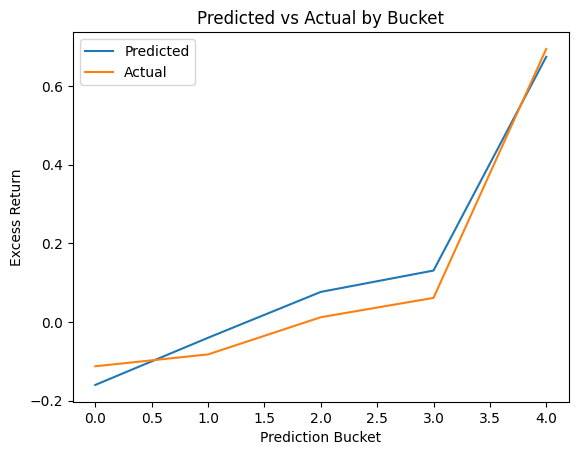

In [21]:
import matplotlib.pyplot as plt

plt.plot(bucket_stats.index, bucket_stats["pred_mean"], label="Predicted")
plt.plot(bucket_stats.index, bucket_stats["actual_mean"], label="Actual")

plt.xlabel("Prediction Bucket")
plt.ylabel("Excess Return")
plt.title("Predicted vs Actual by Bucket")
plt.legend()
plt.show()

In [22]:
print(bucket_stats["actual_mean"].is_monotonic_increasing)

True


In [23]:
bucket_stats

,pred_mean,actual_mean,delta_mean,delta_std,count
pred_bucket,,,,,
0,-0.159970,-0.112502,-0.047467,0.544618,2223
1,-0.040018,-0.082346,0.042328,0.587501,2222
2,0.076601,0.012219,0.064381,0.630283,2223
3,0.130961,0.061416,0.069545,1.256793,2222
4,0.674656,0.694656,-0.020000,3.908288,2223


In [24]:
# ======================================
# Portfolio Engine
# ======================================

import numpy as np

def build_portfolio_dynamic(df, risk_level="medium"):
    
    def construct(x):
        n = len(x)
        
        # --- Risk configurations ---
        if risk_level == "low":
            k = max(10, int(n * 0.3))
            power = 0.3
            
        elif risk_level == "medium":
            k = max(10, int(n * 0.2))
            power = 0.6
            
        elif risk_level == "high":
            k = 5
            power = 0.8
            
        else:
            raise ValueError("risk_level must be low, medium, or high")
        
        subset = x.nlargest(k, "calibrated_pred").copy()
        
        # --- Rank-based weighting ONLY ---
        ranks = subset["calibrated_pred"].rank(method="first")
        w = ranks ** power
        
        if w.sum() == 0:
            subset["weight"] = 1 / len(subset)
        else:
            subset["weight"] = w / w.sum()
        
        return subset

    # --- Build portfolio ---
    portfolio = (
        df.groupby("date", group_keys=False)
        .apply(construct)
        .reset_index(drop=True)
    )
    
    # --- Compute cohort returns ---
    returns = portfolio.groupby("date", group_keys=False).apply(
        lambda x: (x["excess_fwd_3y_return"] * x["weight"]).sum()
    )
    
    returns = returns.reset_index(drop=True)
    
    
    return portfolio, returns

In [25]:
# ======================================
# Run Strategies
# ======================================
portfolio_low, returns_low = build_portfolio_dynamic(test_df, "low")
portfolio_med, returns_med = build_portfolio_dynamic(test_df, "medium")
portfolio_high, returns_high = build_portfolio_dynamic(test_df, "high")

/var/folders/l3/hj4t10p12gs0m_nkjpjr9kqr0000gp/T/ipykernel_44031/1488893153.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(construct)
/var/folders/l3/hj4t10p12gs0m_nkjpjr9kqr0000gp/T/ipykernel_44031/1488893153.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = portfolio.groupby("date", group_keys=False).apply(
/var/folders/l3/hj4t10p12gs0m_nkjpjr9kqr0000gp/T/ipykernel_44031/14888931

In [26]:
benchmark_returns = test_df.groupby('date')['fwd_3y_benchmark_return'].mean()
benchmark_returns

date
2021-01-29    0.381954
2021-02-26    0.396459
2021-03-31    0.369846
2021-04-30    0.264990
2021-05-28    0.312330
2021-06-30    0.346505
2021-07-30    0.270178
2021-08-31    0.275250
2021-09-30    0.382774
2021-10-29    0.299442
2021-11-30    0.385371
2021-12-31    0.309779
2022-01-31    0.403282
2022-02-28    0.395325
2022-03-31    0.166806
2022-04-29    0.417073
2022-05-31    0.500541
2022-06-30    0.715709
2022-07-29    0.590359
2022-08-31    0.713085
2022-09-30    0.952009
2022-10-31    0.828109
2022-11-30    0.752562
2022-12-22    0.877216
2022-12-23    0.852650
Name: fwd_3y_benchmark_return, dtype: float64

In [27]:
# ======================================
# Cohort Performance Summary (3Y Horizon)
# ======================================

def summarize(name, returns, benchmark_returns):
    print(f"\n{name}")
    print("-" * len(name))
    
    # align safely
    returns = returns.reset_index(drop=True)
    benchmark_returns = benchmark_returns.reset_index(drop=True)
    
    mean_ret = returns.mean()
    median_ret = returns.median()
    std_ret = returns.std()
    alpha = mean_ret - benchmark_returns.mean()
    
    # safe hit rate
    hit_rate = (returns > benchmark_returns).mean()
    
    print("Mean 3Y Return:", mean_ret)
    print("Median 3Y Return:", median_ret)
    print("Std:", std_ret)
    print("Alpha vs Benchmark:", alpha)
    print("Hit Rate:", hit_rate)

In [28]:
summarize("Low Risk", returns_low, benchmark_returns)
summarize("Medium Risk", returns_med, benchmark_returns)
summarize("High Risk", returns_high, benchmark_returns)


Low Risk
--------
Mean 3Y Return: 0.5289403216418271
Median 3Y Return: 0.35725612177094435
Std: 0.6281610214975405
Alpha vs Benchmark: 0.0425562003116563
Hit Rate: 0.52

Medium Risk
-----------
Mean 3Y Return: 0.7515531609411993
Median 3Y Return: 0.41797016692507877
Std: 0.9300415346214369
Alpha vs Benchmark: 0.26516903961102845
Hit Rate: 0.6

High Risk
---------
Mean 3Y Return: 1.2881067254963618
Median 3Y Return: 0.6221061112574782
Std: 1.9995018324784137
Alpha vs Benchmark: 0.801722604166191
Hit Rate: 0.68


In [29]:
# ======================================
# Behavior Sanity Check
# ======================================

print("\nExpected Behavior:")
print("Low Risk  → Higher median, lower std")
print("High Risk → Higher mean, higher std")

print("\nActual:")
print("Low Median:", returns_low.median())
print("Med Median:", returns_med.median())
print("High Median:", returns_high.median())

print("\nLow Std:", returns_low.std())
print("Med Std:", returns_med.std())
print("High Std:", returns_high.std())


Expected Behavior:
Low Risk  → Higher median, lower std
High Risk → Higher mean, higher std

Actual:
Low Median: 0.35725612177094435
Med Median: 0.41797016692507877
High Median: 0.6221061112574782

Low Std: 0.6281610214975405
Med Std: 0.9300415346214369
High Std: 1.9995018324784137


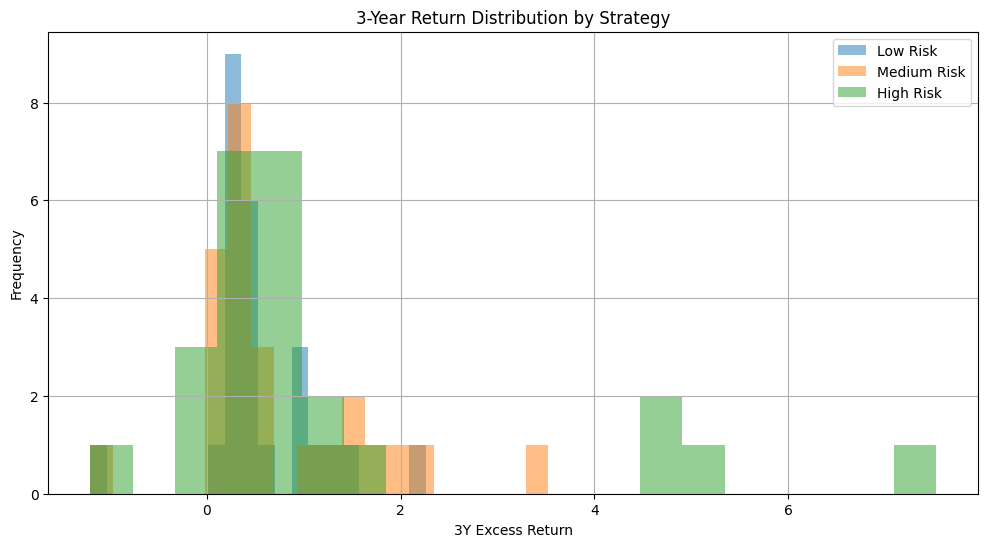

In [30]:
# ======================================
# Cohort Return Distribution (3Y)
# ======================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

returns_low.hist(alpha=0.5, bins=20, label="Low Risk")
returns_med.hist(alpha=0.5, bins=20, label="Medium Risk")
returns_high.hist(alpha=0.5, bins=20, label="High Risk")

plt.legend()
plt.title("3-Year Return Distribution by Strategy")
plt.xlabel("3Y Excess Return")
plt.ylabel("Frequency")

plt.show()

In [31]:
!jupyter nbconvert --to html stock_signal_engine_v4.ipynb

[NbConvertApp] Converting notebook stock_signal_engine_v4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 486023 bytes to stock_signal_engine_v4.html


In [32]:
from IPython.display import FileLink

FileLink("stock_signal_engine_v4.html")

/Users/neilyejjey/stock_signal_engine_v1/notebooks/stock_signal_engine_v4.html